In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.linear_model import LinearRegression


# -----------------------------------------------------------
# 1. Load and prepare WIT data
# -----------------------------------------------------------
# Automatically load your CSV from the specified path
csv_path = "ginini_00_10.csv"                             #ACTION: Add CSV output form WIT tool - generates in DEA_products/
df = pd.read_csv(csv_path)

# Convert date and sort
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Key fractional cover columns
components = ["pv", "npv", "bs", "wet", "water"]

In [2]:
# ============================================================
# 2. Define harmonic + trend model (CCDC-style)
# ============================================================

def fit_harmonic_trend(dates, values, harmonics=1):
    """
    Fits a harmonic + trend model to capture seasonal and gradual variation:
    y = a0 + a1*t + Σ [b*sin(2πk*t/T) + c*cos(2πk*t/T)]
    """
    n = len(values)
    if n < 6:
        return None, None, None

    t = (dates - dates.min()).dt.days.values
    T = 365.25  # 1 year
    X = [np.ones(n), t]

    for k in range(1, harmonics + 1):
        X.append(np.sin(2 * np.pi * k * t / T))
        X.append(np.cos(2 * np.pi * k * t / T))

    X = np.vstack(X).T
    model = LinearRegression().fit(X, values)
    y_pred = model.predict(X)
    residuals = values - y_pred
    rmse = np.sqrt(np.mean(residuals ** 2))

    return y_pred, residuals, rmse


In [3]:
# ============================================================
# 3. Detect abrupt and gradual changes
# ============================================================

def detect_ccdc_changes(dates, values, threshold_factor=1.5, consecutive_obs=3):
    """
    Detects abrupt and gradual changes in time series using residuals from a harmonic model.
    - Abrupt: residuals exceed MAD-based threshold for multiple consecutive points.
    - Gradual: sustained slope changes beyond rolling std threshold.
    """
    y_pred, residuals, rmse = fit_harmonic_trend(dates, values, harmonics=1)
    if y_pred is None:
        return [], [], None

    # ----- Abrupt changes -----
    mad = np.median(np.abs(residuals - np.median(residuals)))
    threshold = threshold_factor * mad
    exceed = np.abs(residuals) > threshold

    abrupt_dates = []
    i = 0
    while i < len(exceed):
        if exceed[i]:
            start = i
            count = 1
            while i + 1 < len(exceed) and exceed[i + 1]:
                count += 1
                i += 1
            if count >= consecutive_obs:
                abrupt_dates.append(dates.iloc[start])
        i += 1

    # ----- Gradual changes -----
    window = max(5, len(values) // 10)
    slopes = pd.Series(values).rolling(window).apply(lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True)
    slope_threshold = 0.5 * np.nanstd(values)
    gradual_dates = dates[np.abs(slopes) > slope_threshold].iloc[::window].tolist()

    return abrupt_dates, gradual_dates, rmse



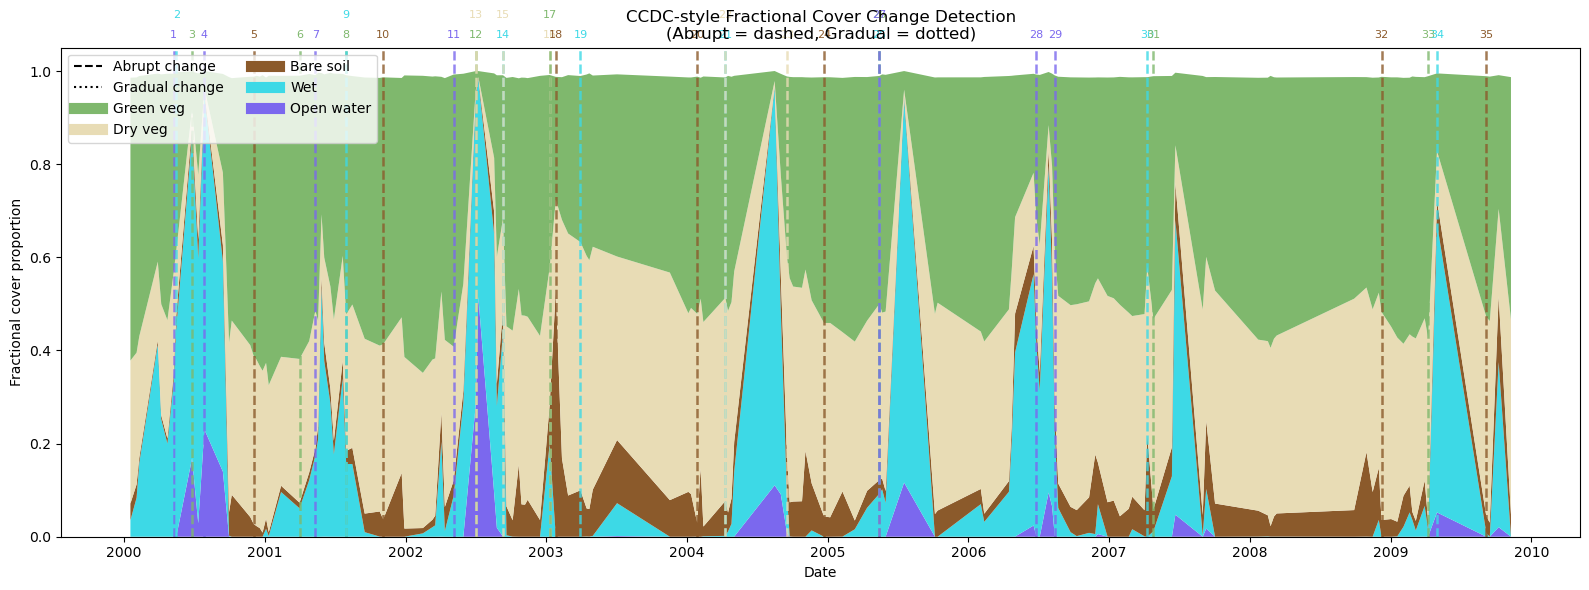

In [4]:
# ============================================================
# 4. Apply to all components and collect changes
# ============================================================

change_summary = []
# Reverse order: Open water at bottom
components = ["pv", "npv", "bs", "wet", "water"]

color_map = {'water': '#7B68EE', 'wet': '#3DD9E6', 'bs': '#8B5A2B',
             'npv': '#E8DCB5', 'pv': '#7FB86D'}
label_map = {'water': 'Open water', 'wet': 'Wet', 'bs': 'Bare soil',
             'npv': 'Dry veg', 'pv': 'Green veg'}

# --- Plot setup
fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(df['date'],
             *[df[c] for c in components[::-1]],
             labels=[label_map[c] for c in components[::-1]],
             colors=[color_map[c] for c in components[::-1]])

# --- Run CCDC-style detection for each component
for c in components:
    abrupt_dates, gradual_dates, rmse = detect_ccdc_changes(df["date"], df[c])

    for change_type, dates in [("Abrupt", abrupt_dates), ("Gradual", gradual_dates)]:
        for d in dates:
            idx = df.index[df["date"] == d][0]
            pre_window = 3 if change_type == "Abrupt" else 5
            post_window = 3 if change_type == "Abrupt" else 5

            pre = df[c].iloc[max(0, idx-pre_window):idx].mean()
            post = df[c].iloc[idx:min(len(df), idx+post_window)].mean()
            pct_change = ((post - pre) / pre) * 100 if pre != 0 else np.nan

            # --- Determine actual direction of change using slope ---
            if 1 < idx < len(df) - 1:
                prev_val = df[c].iloc[idx - 1]
                next_val = df[c].iloc[idx + 1]
                diff = next_val - prev_val
            else:
                diff = np.nan

            # --- Create interpretation text based on direction ---
            if np.isnan(diff):
                desc = "Insufficient data to interpret change."
            else:
                if c == "pv":
                    desc = "Expansion of green vegetation" if diff > 0 else "Reduction of photosynthetic vegetation"
                elif c == "npv":
                    desc = "Increase in dry/non-photosynthetic vegetation" if diff > 0 else "Decline in dry vegetation"
                elif c == "bs":
                    desc = "Increase in exposed bare ground" if diff > 0 else "Decline in bare soil (possible vegetation regrowth)"
                elif c == "wet":
                    desc = "Expansion of moist/wet surface areas" if diff > 0 else "Drying trend in wet areas"
                elif c == "water":
                    desc = "Expansion of open water areas" if diff > 0 else "Contraction of open water areas"
                else:
                    desc = "Unclassified change"

            change_summary.append({
                "Component": c,
                "Date": d,
                "Type": change_type,
                "Change_%": round(pct_change, 2),
                "Description": desc
            })

# ============================================================
# 5. Sort by date and assign IDs chronologically
# ============================================================

change_df = pd.DataFrame(change_summary)

if not change_df.empty:
    change_df["Date"] = pd.to_datetime(change_df["Date"], errors="coerce")
    change_df = change_df.sort_values("Date").reset_index(drop=True)
    change_df["ID"] = np.arange(1, len(change_df) + 1)
else:
    change_df = pd.DataFrame([{
        "ID": np.nan,
        "Component": np.nan,
        "Date": np.nan,
        "Type": np.nan,
        "Change_%": np.nan,
        "Description": np.nan
    }])

# ============================================================
# 6. Plot change lines using sorted IDs (with overlap handling)
# ============================================================

# To avoid overlap, shift text vertically for lines within ±10 days
y_offset_map = {}
for _, row in change_df.iterrows():
    if pd.isna(row["Date"]):
        continue

    date_key = pd.to_datetime(row["Date"]).strftime("%Y-%m-%d")
    nearby = [d for d in y_offset_map if abs((pd.to_datetime(d) - pd.to_datetime(date_key)).days) < 10]
    offset = len(nearby) * 0.04  # stack vertically if close
    y_offset_map[date_key] = offset

    color = color_map.get(row["Component"], "black")
    linestyle = '--' if row["Type"] == "Abrupt" else ':'

    ax.axvline(row["Date"], color=color, linestyle=linestyle, linewidth=1.8, alpha=0.8)
    ax.text(row["Date"], 1.02 + y_offset_map[date_key], str(int(row["ID"])), color=color,
            fontsize=8, ha='center', transform=ax.get_xaxis_transform())

# --- Legend for change types
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color='black', linestyle='--', label='Abrupt change'),
    Line2D([0], [0], color='black', linestyle=':', label='Gradual change')
]
ax.legend(handles=legend_lines + [
    Line2D([0], [0], color=color_map[c], linewidth=8, label=label_map[c])
    for c in components
], loc="upper left", ncol=2)

ax.set_title("CCDC-style Fractional Cover Change Detection\n(Abrupt = dashed, Gradual = dotted)")
ax.set_ylabel("Fractional cover proportion")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 7. Save output CSV (chronological order, NaN-safe)
# ============================================================

output_csv = csv_path.replace(".csv", "_CCDC_ChangeSummary.csv")
change_df.to_csv(output_csv, index=False, na_rep="NaN")

print(f"✅ Change summary saved to: {output_csv}")
print(change_df)

✅ Change summary saved to: ginini_00_10_CCDC_ChangeSummary.csv
   Component                       Date    Type   Change_%  \
0      water 2000-05-08 23:42:49.967418  Abrupt        NaN   
1        wet 2000-05-15 23:48:35.324805  Abrupt     118.20   
2         pv 2000-06-25 23:42:24.846675  Abrupt     -75.06   
3      water 2000-07-27 23:41:53.481601  Abrupt      87.65   
4         bs 2000-12-02 23:41:02.461123  Abrupt     -62.57   
5         pv 2001-03-31 23:46:36.651641  Abrupt     -10.24   
6      water 2001-05-11 23:40:38.429070  Abrupt        NaN   
7         pv 2001-07-30 23:39:51.469601  Abrupt      13.62   
8        wet 2001-07-30 23:39:51.469601  Abrupt     -59.90   
9         bs 2001-11-03 23:39:03.888393  Abrupt      49.17   
10     water 2002-05-05 23:45:19.204468  Abrupt  104321.41   
11        pv 2002-07-01 23:39:07.892111  Abrupt     -85.22   
12       npv 2002-07-01 23:39:07.892111  Abrupt     -85.79   
13       wet 2002-09-10 23:44:24.502080  Abrupt     -65.69   
14     